### Learning Goal
- **What concept is this notebook teaching?** Logistic Regression and the Sigmoid function.
- **Why does it matter?** It adapts linear math to predict probabilities (0 to 1) for classification.

In [16]:
import pandas as pd

df = pd.read_csv('./data/diabetes.csv')

In [17]:
import numpy as np

pd.set_option('display.max_rows', None)

pd.set_option('display.max_columns', None)

pd.set_option('display.max_colwidth', None)

# print(df)

print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.describe())
print(df[df.duplicated(keep=False)])
print(df.isna().sum())

df.drop_duplicates(inplace=True)

zero_rows = df[
    (df['Age'] == 0) |
    (df['Insulin'] == 0) | 
    (df['SkinThickness'] == 0) | 
    (df['BloodPressure'] == 0) | 
    (df['Glucose'] == 0) |
    (df['BMI'] == 0) |
    (df['DiabetesPedigreeFunction'] == 0)
]

print(zero_rows)

cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

df[cols_to_impute] = df[cols_to_impute].replace(0, np.nan)

df[cols_to_impute] = df[cols_to_impute].fillna(df[cols_to_impute].mean())

print(df.isna().sum())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

### Visualization Interpretation
- **What pattern is visible?** An S-curve fitting binary (0 or 1) data points.
- **Why does it happen?** The Sigmoid function guarantees a valid probability output.

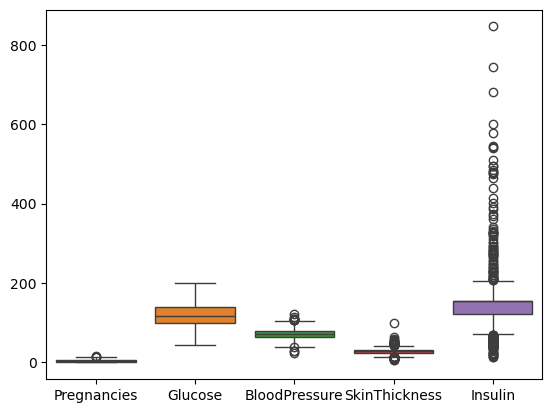

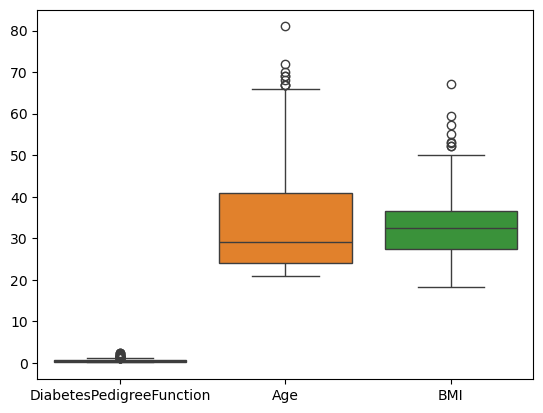

Lower bound: 70.42766497461929 
 Upper bound: 206.62055837563452
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
20             3    126.0           88.0           41.0    235.0  39.3   
31             3    158.0           76.0           36.0    245.0  31.6   
39             4    111.0           72.0           47.0    207.0  37.1   
43             9    171.0          110.0           24.0    240.0  45.4   
53             8    176.0           90.0           34.0    300.0  33.7   
54             7    150.0           66.0           42.0    342.0  34.7   
111            8    155.0           62.0           26.0    495.0  34.0   
132            3    170.0           64.0           37.0    225.0  34.5   
186            8    181.0           68.0           36.0    495.0  30.1   
195            5    158.0           84.0           41.0    210.0  39.4   
206            8    196.0           76.0           29.0    280.0  37.5   
215           12    151.0           70.0       

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin']])
plt.show()


sns.boxplot(df[['DiabetesPedigreeFunction', 'Age', 'BMI']])
plt.show()

q1 = df['Insulin'].quantile(0.25)
q3 = df['Insulin'].quantile(0.75)

IQR = q3 - q1
Lower_bound = q1 - 1.5 * IQR
Upper_bound = q3 + 1.5 * IQR

print(f'Lower bound: {Lower_bound} \n Upper bound: {Upper_bound}')

outliers_df = df[(df['Insulin'] < Lower_bound) | (df['Insulin'] > Upper_bound)]

print(outliers_df[
    (outliers_df['BMI'] > 30) &
    ((outliers_df['Pregnancies'] > 2) &
    (outliers_df['DiabetesPedigreeFunction'] > 0.35))
])


### Visualization Analysis: General Plot Interpretation
- **Marking Values:** Always identify the max/min peaks, intersections, and the general trend line (upward, downward, or flat).
- **Correct Interpretation:** Visualizations bridge the gap between raw mathematical outputs and human intuition. Look for structural patterns that confirm or deny your hypotheses.
- **How to Interpret:** Read the axes first. The X-axis is the independent variable, the Y-axis is the dependent reaction.
- **Common Mistakes:** Producing a beautiful graph but failing to extract a single actionable business or engineering decision from it.

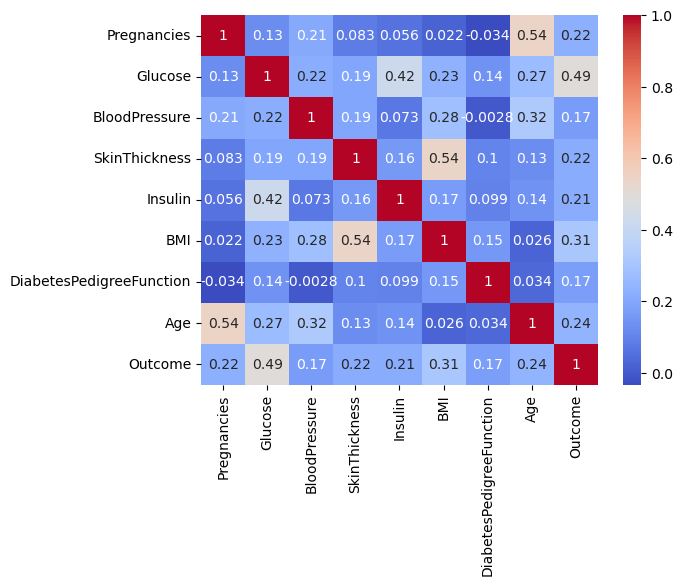

In [ ]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()


sns.pairplot(
    df.select_dtypes(include='number'), 
    kind='reg', 
    plot_kws={'line_kws':{'color':'red'}}
)
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [ ]:
df['age_range'] = pd.cut(
    df['Age'], 
    bins=[0, 30, 45, 60, 120], 
    labels=['young_adult', 'adult', 'middle_age', 'senior'],
    include_lowest=True)



[ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14]


In [ ]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.show()

### Visualization Analysis: Correlation Heatmap
- **Marking Values:** Look specifically for values approaching 1.0 (strong positive correlation) or -1.0 (strong negative correlation) against the target variable.
- **Correct Interpretation:** Features with high absolute correlation to the target are your strongest predictors. Features highly correlated with *each other* indicate multi-collinearity.
- **How to Interpret:** Darker or more intense colors represent stronger mathematical relationships. A value of 0 means zero linear relationship.
- **Common Mistakes:** Assuming correlation implies causation. Also, failing to drop one of two highly correlated features (e.g., dropping 'Tax' if it correlates 0.95 with 'Price') which confuses linear models.

In [22]:
import numpy as np

X = df.drop(columns='Outcome')
y = df['Outcome']

print(X.select_dtypes(include='number').skew())
print(y.skew())

# Project categorical variables into orthogonal binary vectors to prevent the model from falsely assuming ordinal relationships.
X_encoded = pd.get_dummies(X, drop_first=True)

Pregnancies                 0.901674
Glucose                     0.532719
BloodPressure               0.137305
SkinThickness               0.822173
Insulin                     3.019084
BMI                         0.598253
DiabetesPedigreeFunction    1.919911
Age                         1.129597
dtype: float64
0.635016643444986


In [23]:
from sklearn.model_selection import train_test_split

# Isolate a hold-out test set to provide an unbiased evaluation of generalization error and detect data leakage.
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, random_state=42, train_size=0.80)


### Experiment
- **What are we changing?** We are mapping linear outputs through a Sigmoid curve.
- **What do we expect to happen?** Outputs of 1.5 or -3.0 will be squashed between 0 and 1.

In [24]:
from sklearn.preprocessing import StandardScaler

# Standardize features by removing the mean and scaling to unit variance. Crucial for distance-based algorithms (e.g., kNN, SVM).
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
from sklearn.linear_model import LogisticRegressionCV

model = LogisticRegressionCV(
    cv=5,
    scoring='accuracy',
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)
print(y_prob[:5])

print(model.C_)

[[0.65684984 0.34315016]
 [0.86892944 0.13107056]
 [0.91378676 0.08621324]
 [0.83242507 0.16757493]
 [0.44048848 0.55951152]]
[21.5443469]


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

TN, FP, FN, TP = cm.ravel()

print(f"TN: {TN}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"TP: {TP}")

[[85 14]
 [21 34]]
TN: 85
FP: 14
FN: 21
TP: 34


In [27]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

specificity = TN / (TN + FP)
print(f"Specificity: {specificity:.4f}")

type1_error = FP / (FP + TN)
print(f"Type I Error: {type1_error:.4f}")

type2_error = FN / (FN + TP)
print(f"Type II Error: {type2_error:.4f}")

Accuracy: 0.7727
Precision: 0.7083
Recall: 0.6182
F1: 0.6182
Specificity: 0.8586
Type I Error: 0.1414
Type II Error: 0.3818


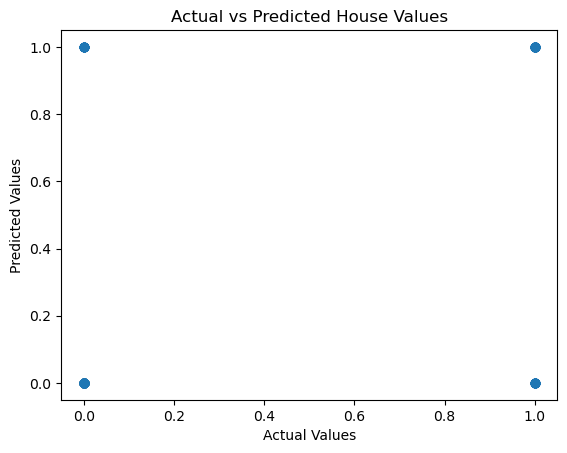

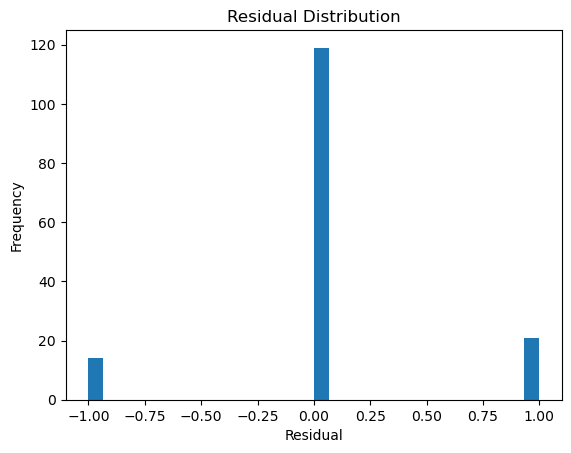

In [28]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted House Values")

plt.show()

residuals = y_test - y_pred

plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.show()

### Visualization Analysis: Scatter/Pair Plot
- **Marking Values:** Look for distinct clusters, straight lines, or chaotic clouds of points.
- **Correct Interpretation:** A clear diagonal trend indicates a linear relationship. Distinct, separated blobs indicate the data is highly clusterable or easily classified.
- **How to Interpret:** Each dot represents a single row of data plotted across two feature dimensions.
- **Common Mistakes:** Over-interpreting a 2D scatter plot when the model actually operates in high-dimensional space (PCA should be used to crush dimensions first).

In [29]:
feature_importance = pd.Series(
    model.coef_[0],
    index=X_encoded.columns
).sort_values(ascending=False)

print(feature_importance)

Glucose                        1.150465
BMI                            0.687551
age_range_adult                0.429646
age_range_middle_age           0.381875
Age                            0.331981
DiabetesPedigreeFunction       0.180042
SkinThickness                  0.047773
pregnancies_range_moderate     0.000000
pregnancies_range_high         0.000000
pregnancies_range_very high    0.000000
Pregnancies                   -0.004573
Insulin                       -0.133460
age_range_senior              -0.182408
BloodPressure                 -0.198634
dtype: float64


### Common Mistakes
- **Beginner Mistake:** Treating Logistic Regression as a regression algorithm. It is strictly for classification.

### Practical Takeaway
- **Industry Application:** Baseline model for credit scoring (Approved vs Denied) due to its perfect interpretability.

### Key Insight
- **Memorable lesson:** Logistic Regression doesn't predict classes; it predicts the *probability* of a class.